# Access 4DMED-SEA Sea-Surface Salinity
    * Original Data Source: https://zenodo.org/records/13753090
    * Reference:  https://doi.org/10.3390/rs14102502
    * OSC entry: https://opensciencedata.esa.int/products/4dmed-2d-sss/collection
    * License: CC-BY-4.0

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/sssd.zarr'

In [3]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 31GB
Dimensions:    (time: 2557, depth: 1, lat: 378, lon: 1012)
Coordinates:
  * time       (time) datetime64[ns] 20kB 2016-01-01T12:00:00 ... 2022-12-31T...
  * depth      (depth) float32 4B 0.0
  * lat        (lat) float32 2kB 30.27 30.31 30.35 30.4 ... 45.9 45.94 45.98
  * lon        (lon) float32 4kB -6.062 -6.021 -5.979 ... 35.98 36.02 36.06
Data variables:
    dos        (time, depth, lat, lon) float64 8GB dask.array<chunksize=(30, 1, 378, 1012), meta=np.ndarray>
    dos_error  (time, depth, lat, lon) float64 8GB dask.array<chunksize=(30, 1, 378, 1012), meta=np.ndarray>
    sos        (time, depth, lat, lon) float64 8GB dask.array<chunksize=(30, 1, 378, 1012), meta=np.ndarray>
    sos_error  (time, depth, lat, lon) float64 8GB dask.array<chunksize=(30, 1, 378, 1012), meta=np.ndarray>
Attributes: (12/16)
    Conventions:            CF-1.7
    title:                  Mediterranean Analysed Sea Surface Salinity and D...
    institution:            CNR
    netcdf_version_id:      4.9.3-development of Jun  4 2023 14:13:36 
    creation_date:          Mon 11 Sep 2023 09:30:47
    product_version:        1.0
    ...                     ...
    northernmost_latitude:  45.979168
    Scaling_Equation:       (scale_factor*data) + add_offset
    grid_resolution:        0.0416 degrees
    references:             Buongiorno Nardelli, B., R. Droghei, and R. Santo...
    history:                Fri Feb  9 09:26:09 2024: ncatted -O -a reference...
    NCO:                    netCDF Operators version 4.8.1 (Homepage = http:/...

## Plot sea surface salinity for a single date

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# Choose date
date = np.datetime64("2020-06-15")


# Select FSLE for that date
sos_day = ds["sos"].sel(time=date,depth=0,method="nearest", drop=True)
sos_day

<xarray.DataArray 'sos' (lat: 378, lon: 1012)> Size: 3MB
dask.array<getitem, shape=(378, 1012), dtype=float64, chunksize=(378, 1012), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 2kB 30.27 30.31 30.35 30.4 ... 45.85 45.9 45.94 45.98
  * lon      (lon) float32 4kB -6.062 -6.021 -5.979 -5.937 ... 35.98 36.02 36.06
Attributes:
    long_name:      sea surface salinity
    standard_name:  sea_surface_salinity
    units:          .0001

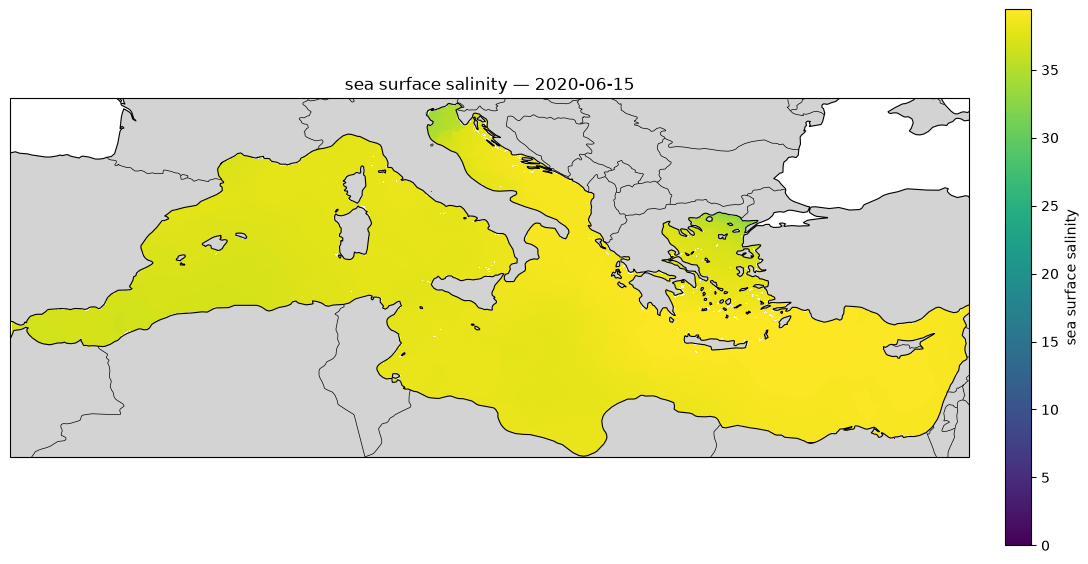

In [14]:
# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    sos_day.lon,
    sos_day.lat,
    sos_day,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)


# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("sea surface salinity")

ax.set_title(f"sea surface salinity - {date}")

plt.tight_layout()
plt.show()